## **1. Data Exploration & Preparation**

This notebook covers:
- Loading the disaster tweet dataset
- Quick data inspection
- Missing-value analysis
- Basic exploratory data analysis
- Text cleaning
- Train/test split
- Saving prepared files for later notebooks
- Summary

In [18]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

DATA_PATH = Path("twitter_disaster (1).csv")
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding="latin1")
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [19]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (7613, 5)

Columns: ['id', 'keyword', 'location', 'text', 'target']

Data types:
id           int64
keyword     object
location    object
text        object
target       int64
dtype: object


## **Data dictionary**

Expected columns:
- `id`: unique tweet identifier
- `keyword`: optional disaster-related keyword
- `location`: optional user location
- `text`: raw tweet text
- `target`: label (`1 = disaster`, `0 = non-disaster`)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [21]:
df.isna().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

# **Basic target distribution**

In [22]:
target_counts = df["target"].value_counts().sort_index()
target_counts.index = ["Non-Disaster (0)", "Disaster (1)"]
target_counts

Non-Disaster (0)    4342
Disaster (1)        3271
Name: count, dtype: int64

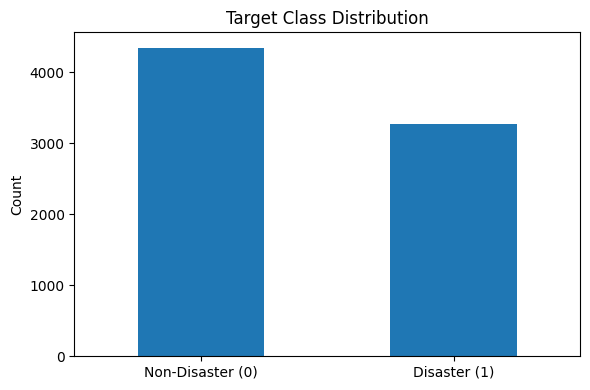

In [23]:
plt.figure(figsize=(6,4))
target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Adding a few useful EDA features**

In [24]:
df["text_length_chars"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().apply(len)
df["has_hashtag"] = df["text"].astype(str).str.contains(r"#")
df["has_mention"] = df["text"].astype(str).str.contains(r"@")
df["has_url"] = df["text"].astype(str).str.contains(r"http|www", case=False)

df[["text_length_chars", "word_count", "has_hashtag", "has_mention", "has_url"]].head()

,text_length_chars,word_count,has_hashtag,has_mention,has_url
0,69,13,True,False,False
1,38,7,False,False,False
2,133,22,False,False,False
3,65,8,True,False,False
4,88,16,True,False,False


In [25]:
eda_summary = df.groupby("target")[["text_length_chars", "word_count", "has_hashtag", "has_mention", "has_url"]].mean()
eda_summary

,text_length_chars,word_count,has_hashtag,has_mention,has_url
target,,,,,
0,95.981345,14.662137,0.201520,0.312759,0.406034
1,108.444207,15.136044,0.264445,0.206665,0.656374


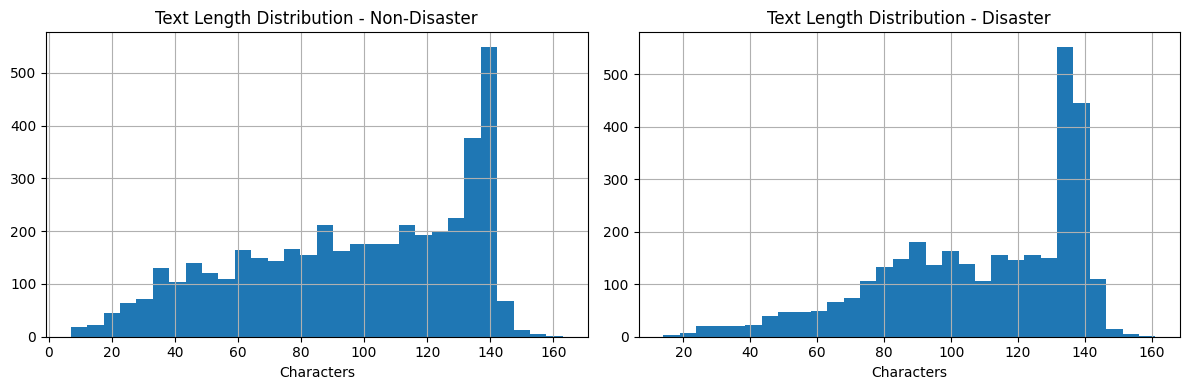

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df["target"] == 0]["text_length_chars"].hist(bins=30, ax=axes[0])
axes[0].set_title("Text Length Distribution - Non-Disaster")
axes[0].set_xlabel("Characters")

df[df["target"] == 1]["text_length_chars"].hist(bins=30, ax=axes[1])
axes[1].set_title("Text Length Distribution - Disaster")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

**Top keywords (after filling missing values)**

In [27]:
top_keywords = (
    df["keyword"]
    .fillna("missing")
    .value_counts()
    .head(20)
)
top_keywords

keyword
missing        61
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
hellfire       39
famine         39
flames         39
weapon         39
wreckage       39
Name: count, dtype: int64

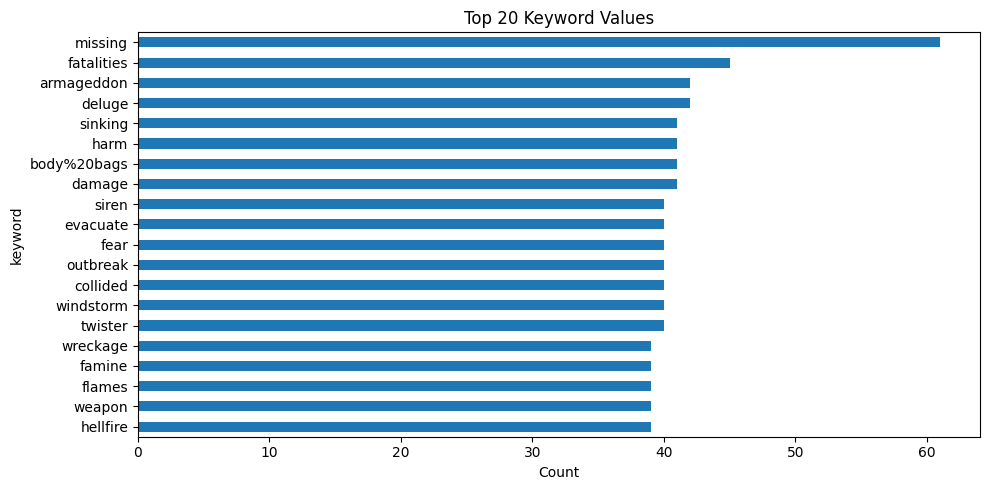

In [28]:
plt.figure(figsize=(10,5))
top_keywords.sort_values().plot(kind="barh")
plt.title("Top 20 Keyword Values")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## **Text cleaning**

This project uses a lightweight custom cleaning function that:
- Lowercases text
- Removes URLs, HTML tags, mentions
- Keeps hashtag words but removes the `#` symbol
- Removes punctuation and extra spaces

This keeps the preprocessing reproducible across training and deployment.

In [29]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      # URLs
    text = re.sub(r"<.*?>", " ", text)               # HTML
    text = re.sub(r"@\w+", " ", text)                # mentions
    text = text.replace("#", " ")                    # keep hashtag word, drop #
    text = re.sub(r"[^a-z0-9\s]", " ", text)         # remove punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()         # extra whitespace
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(10)

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy 20 closed in b...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,i m on top of the hill and i can see a fire in...
8,There's an emergency evacuation happening now ...,there s an emergency evacuation happening now ...
9,I'm afraid that the tornado is coming to our a...,i m afraid that the tornado is coming to our area


# **Simple tokenized version (space-based)**

In [30]:
df["tokens"] = df["clean_text"].str.split()
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place..."
3,13 000 people receive wildfires evacuation ord...,"[13, 000, people, receive, wildfires, evacuati..."
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala..."


# **Filling optional columns so downstream feature engineering is easier**

In [31]:
# Fill optional columns so downstream feature engineering is easier
df["keyword"] = df["keyword"].fillna("missing")
df["location"] = df["location"].fillna("missing")

# Select final working columns
work_df = df[[
    "id", "keyword", "location", "text", "clean_text", "tokens",
    "text_length_chars", "word_count", "has_hashtag", "has_mention", "has_url", "target"
]].copy()

work_df.head()

,id,keyword,location,text,clean_text,tokens,text_length_chars,word_count,has_hashtag,has_mention,has_url,target
0,1,missing,missing,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth...",69,13,True,False,False,1
1,4,missing,missing,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]",38,7,False,False,False,1
2,5,missing,missing,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place...",133,22,False,False,False,1
3,6,missing,missing,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...,"[13, 000, people, receive, wildfires, evacuati...",65,8,True,False,False,1
4,7,missing,missing,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala...",88,16,True,False,False,1


# **Selecting final working columns**

In [32]:
work_df = df[[
    "id", "keyword", "location", "text", "clean_text", "tokens",
    "text_length_chars", "word_count", "has_hashtag", "has_mention", "has_url", "target"
]].copy()

work_df.head()

,id,keyword,location,text,clean_text,tokens,text_length_chars,word_count,has_hashtag,has_mention,has_url,target
0,1,missing,missing,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth...",69,13,True,False,False,1
1,4,missing,missing,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]",38,7,False,False,False,1
2,5,missing,missing,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place...",133,22,False,False,False,1
3,6,missing,missing,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...,"[13, 000, people, receive, wildfires, evacuati...",65,8,True,False,False,1
4,7,missing,missing,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala...",88,16,True,False,False,1


In [33]:
# Train/test split
X = work_df.drop(columns=["target"])
y = work_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = X_train.copy()
train_df["target"] = y_train.values

test_df = X_test.copy()
test_df["target"] = y_test.values

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain target distribution:")
print(train_df["target"].value_counts(normalize=True))
print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))

Train shape: (6090, 12)
Test shape: (1523, 12)

Train target distribution:
target
0    0.570279
1    0.429721
Name: proportion, dtype: float64

Test target distribution:
target
0    0.570584
1    0.429416
Name: proportion, dtype: float64


In [34]:
train_df.to_csv(OUTPUT_DIR / "train_prepared.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_prepared.csv", index=False)
work_df.to_csv(OUTPUT_DIR / "full_prepared.csv", index=False)

print("Saved:")
for file in OUTPUT_DIR.glob("*.csv"):
    print("-", file)

Saved:
- artifacts\full_prepared.csv
- artifacts\test_prepared.csv
- artifacts\train_prepared.csv


## **Notebook 1 output**

Artifacts created:
- `artifacts/full_prepared.csv`
- `artifacts/train_prepared.csv`
- `artifacts/test_prepared.csv`

These will be used in the next notebook.